# Chapter 3: Data Understanding & Preparation
### Forensic Appliance Detection System

This interactive notebook demonstrates the **Data Understanding** and **Data Preparation** phases (CRISP-DM Phases 2 & 3) of our forensic pipeline. We will execute our actual backend logic against a real uploaded test video to highlight how we handle motion blur, temporal redundancy, geometric aspect ratios, and visual contrast enhancement.

In [2]:
%matplotlib inline
import sys
import os
import cv2
import numpy as np
import matplotlib.pyplot as plt
import warnings
from pathlib import Path
from PIL import Image

# Suppress annoying PyTorch/YOLO FutureWarnings
warnings.filterwarnings("ignore", category=FutureWarning)

# Connect to backend codebase
BACKEND_DIR = Path(os.getcwd()).parent
if str(BACKEND_DIR) not in sys.path:
    sys.path.insert(0, str(BACKEND_DIR))
    
from app.services.yolov5_service import YOLOv5Service
from app.services.vision_rag_service import VisionRAGService

VIDEO_PATH = BACKEND_DIR / "uploads" / "f4603c58-571f-4082-b29a-1b4c67529cc7.mp4"
print(f"Target Video Dataset: {VIDEO_PATH.name}")


A module that was compiled using NumPy 1.x cannot be run in
NumPy 2.3.5 as it may crash. To support both 1.x and 2.x
versions of NumPy, modules must be compiled with NumPy 2.0.
Some module may need to rebuild instead e.g. with 'pybind11>=2.12'.

If you are a user of the module, the easiest solution will be to
downgrade to 'numpy<2' or try to upgrade the affected module.
We expect that some modules will need time to support NumPy 2.

Traceback (most recent call last):  File "<frozen runpy>", line 198, in _run_module_as_main
  File "<frozen runpy>", line 88, in _run_code
  File "c:\Users\chahd\anaconda3\Lib\site-packages\ipykernel_launcher.py", line 17, in <module>
    app.launch_new_instance()
  File "c:\Users\chahd\anaconda3\Lib\site-packages\traitlets\config\application.py", line 992, in launch_instance
    app.start()
  File "c:\Users\chahd\anaconda3\Lib\site-packages\ipykernel\kernelapp.py", line 736, in start
    self.io_loop.start()
  File "c:\Users\chahd\anaconda3\Lib\site-packa

AttributeError: _ARRAY_API not found

ImportError: numpy.core.multiarray failed to import

---
## Part 1: Video Stream Characteristics & Temporal Redundancy
Mobile video contains massive temporal redundancy. We inspect the video to see exactly how much data is being generated.

Video Data Volume:
- Total Frames: 862
- Framerate: 29.80 FPS
- Duration: 28.92 seconds


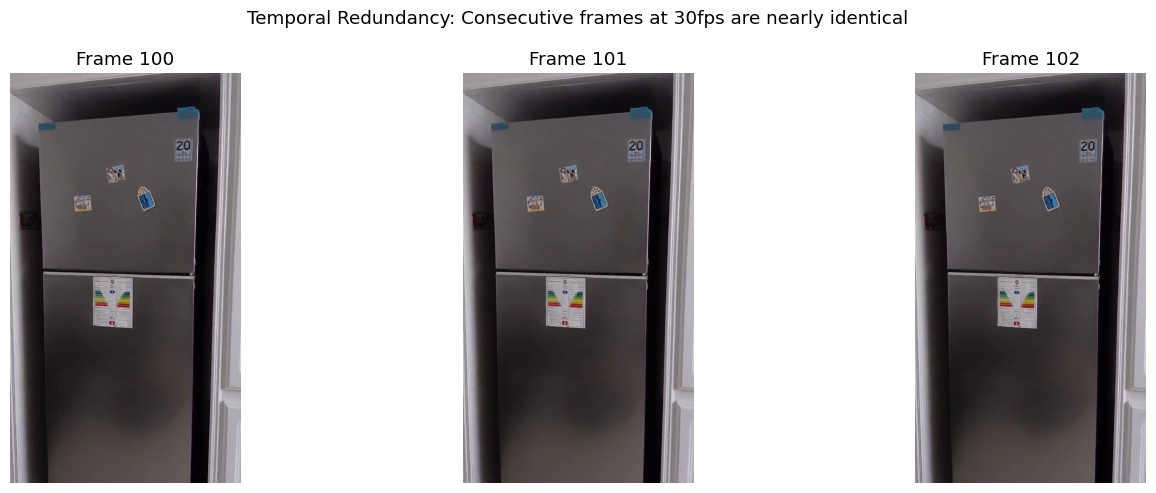

In [ ]:
cap = cv2.VideoCapture(str(VIDEO_PATH))
total_frames = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))
fps = cap.get(cv2.CAP_PROP_FPS)

print(f"Video Data Volume:")
print(f"- Total Frames: {total_frames}")
print(f"- Framerate: {fps:.2f} FPS")
print(f"- Duration: {total_frames/fps:.2f} seconds")

# Extract 3 consecutive frames to show redundancy
fig, axes = plt.subplots(1, 3, figsize=(15, 5))
for i, f_idx in enumerate([100, 101, 102]):
    cap.set(cv2.CAP_PROP_POS_FRAMES, f_idx)
    _, frame = cap.read()
    axes[i].imshow(cv2.cvtColor(frame, cv2.COLOR_BGR2RGB))
    axes[i].set_title(f"Frame {f_idx}")
    axes[i].axis('off')
plt.suptitle("Temporal Redundancy: Consecutive frames at 30fps are nearly identical")
plt.tight_layout()
plt.show()

---
## Part 2: Motion Blur Assessment & Laplacian Sharpness
Rapid camera panning degrades OCR text and logo features. We use the **Laplacian Variance** ($S$) operator to identify and discard blurred frames.
Let's compare Frame 42 (mid-pan blur) against Frame 96 (stabilized candidate).

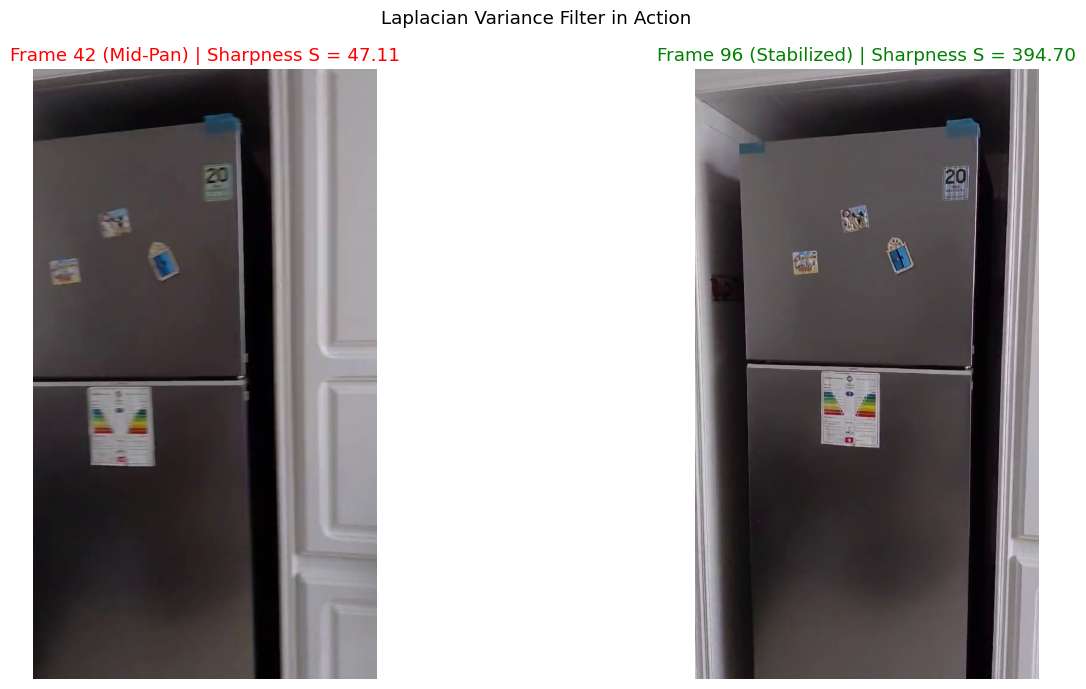

Frame 96 is 8.4x sharper than Frame 42.
The pipeline successfully rejects Frame 42 before it costs cloud API credits.


In [ ]:
def get_sharpness(frame_img):
    gray = cv2.cvtColor(frame_img, cv2.COLOR_BGR2GRAY)
    return cv2.Laplacian(gray, cv2.CV_64F).var()

# Read the Blurry Frame
cap.set(cv2.CAP_PROP_POS_FRAMES, 42)
_, blur_frame = cap.read()
blur_score = get_sharpness(blur_frame)

# Read the Sharp Frame
cap.set(cv2.CAP_PROP_POS_FRAMES, 96)
_, sharp_frame = cap.read()
sharp_score = get_sharpness(sharp_frame)

fig, axes = plt.subplots(1, 2, figsize=(16, 7))
axes[0].imshow(cv2.cvtColor(blur_frame, cv2.COLOR_BGR2RGB))
axes[0].set_title(f"Frame 42 (Mid-Pan) | Sharpness S = {blur_score:.2f}", color='red')
axes[0].axis('off')

axes[1].imshow(cv2.cvtColor(sharp_frame, cv2.COLOR_BGR2RGB))
axes[1].set_title(f"Frame 96 (Stabilized) | Sharpness S = {sharp_score:.2f}", color='green')
axes[1].axis('off')

plt.suptitle("Laplacian Variance Filter in Action")
plt.tight_layout()
plt.show()

print(f"Frame 96 is {sharp_score / blur_score:.1f}x sharper than Frame 42.")
print("The pipeline successfully rejects Frame 42 before it costs cloud API credits.")

---
## Part 3: Object Detection (The YOLOv5 Gatekeeper)
Sharpness alone is not enough! A frame might be perfectly sharp but contain only an empty wall. Before selecting a **Hero Frame**, our local YOLOv5 model scans the sharp candidate frames. If no appliance is detected, the frame is rejected.

Here we test YOLOv5 on two sharp frames: Frame 59 (empty wall) and Frame 96 (refrigerator).

YOLOv5  2026-3-10 Python-3.13.2 torch-2.10.0+cpu CPU



Initializing YOLOv5 (Local AI Filter)...
🚀 Loading YOLOv5 model: c:\Users\chahd\Desktop\DetectionAppPFE\backend\vision_engine\weights\yolov5s.pt
WARNING requirements: C:\Users\chahd\Desktop\DetectionAppPFE\backend\vision_engine\yolov5\requirements.txt not found, check failed.


YOLOv5  2026-3-10 Python-3.13.2 torch-2.10.0+cpu CPU

Adding AutoShape... 


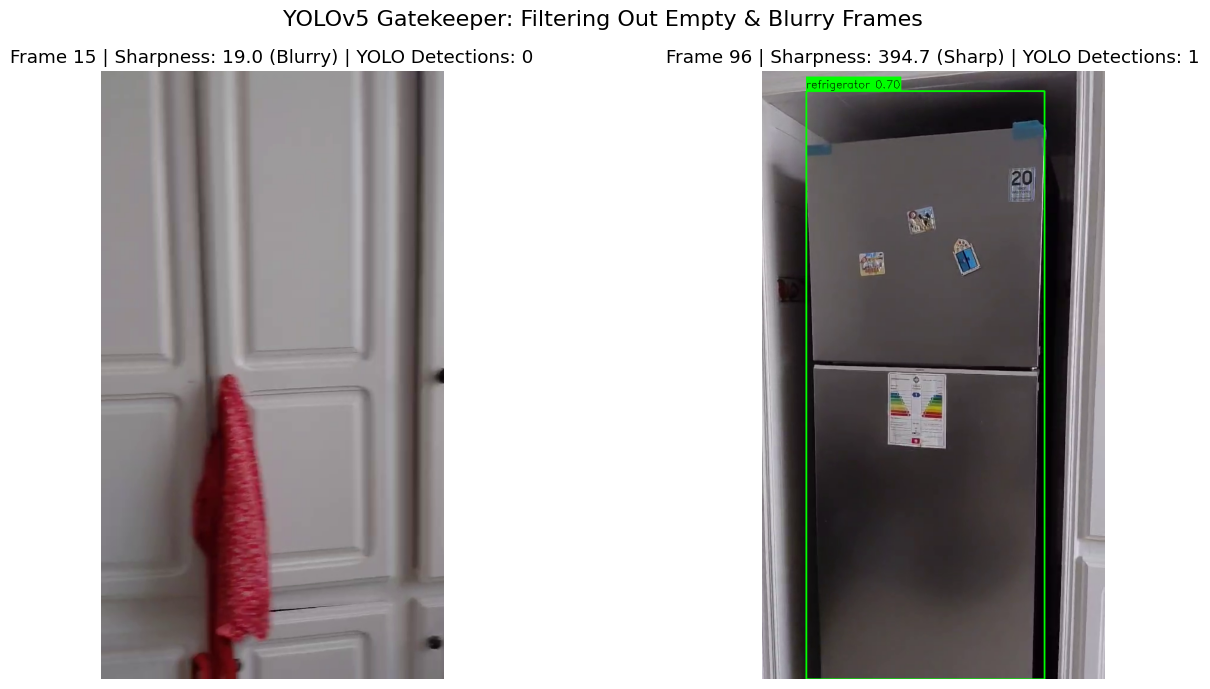

❌ Frame 15 REJECTED: It is blurry, and there is ZERO equipment in the frame.
✅ Frame 96 SELECTED AS HERO FRAME: Detected refrigerator with 0.70 confidence!


In [ ]:
print("Initializing YOLOv5 (Local AI Filter)...")
yolo = YOLOv5Service()

# Extract Frame 15 (Blurry and 100% Empty Wall)
cap.set(cv2.CAP_PROP_POS_FRAMES, 15)
_, empty_frame = cap.read()
empty_rgb = cv2.cvtColor(empty_frame, cv2.COLOR_BGR2RGB)
pil_empty = Image.fromarray(empty_rgb)

# Run Inference on Empty Frame
empty_hits = yolo.detect(pil_empty)
empty_drawn = yolo.draw_detections(pil_empty, empty_hits)

# Run Inference on Frame 96 (Refrigerator)
sharp_rgb = cv2.cvtColor(sharp_frame, cv2.COLOR_BGR2RGB)
pil_sharp = Image.fromarray(sharp_rgb)
sharp_hits = yolo.detect(pil_sharp)
sharp_drawn = yolo.draw_detections(pil_sharp, sharp_hits)

# Plot Results
fig, axes = plt.subplots(1, 2, figsize=(16, 7))

axes[0].imshow(empty_drawn)
axes[0].set_title(f"Frame 15 | Sharpness: {get_sharpness(empty_frame):.1f} (Blurry) | YOLO Detections: {len(empty_hits)}")
axes[0].axis('off')

axes[1].imshow(sharp_drawn)
axes[1].set_title(f"Frame 96 | Sharpness: {sharp_score:.1f} (Sharp) | YOLO Detections: {len(sharp_hits)}")
axes[1].axis('off')

plt.suptitle("YOLOv5 Gatekeeper: Filtering Out Empty & Blurry Frames", fontsize=16)
plt.tight_layout()
plt.show()

if len(empty_hits) == 0:
    print("❌ Frame 15 REJECTED: It is blurry, and there is ZERO equipment in the frame.")

if len(sharp_hits) > 0:
    best_hit = max(sharp_hits, key=lambda x: x['confidence'])
    print(f"✅ Frame 96 SELECTED AS HERO FRAME: Detected {best_hit['class']} with {best_hit['confidence']:.2f} confidence!")

---
## Part 3b: Cloud Inference (Roboflow Custom Workflow)
Once the Local YOLOv5 gatekeeper validates the Hero Frame (Frame 96), it is sent to the Roboflow Cloud API. Our serverless `custom-workflow-3` performs a high-accuracy secondary scan to retrieve exact bounding boxes and classify the forensic target.

Initializing Roboflow Service (Cloud API)...
Sending Hero Frame (Frame 96) to Roboflow custom-workflow-3...
🚀 Calling Roboflow Workflow: custom-workflow-3...
📡 Roboflow Response Status: 200
✅ Roboflow Response: {'outputs': [{'annotated_image': {'type': 'base64', 'value': '/9j/4AAQSkZJRgABAQAAAQABAAD/2wBDAAIBAQEBAQIBAQECAgICAgQDAgICAgUEBAMEBgUGBgYFBgYGBwkIBgcJBwYGCAsICQoKCgoKBggLDAsKDAkKCgr/2wBDAQICAgICAgUDAwUKBwYHCgoKCgoKCgoKCgoKCgoKCgoKCgoKCgoKCgoKCgoKCgoKCgoKCgoKCgoKCgoKCgoKCgr/wAARCAQAAkADASIAAhEBAxEB/8QAHwAAAQUBAQEBAQEAAAAAAAAAAAECAwQFBgcICQoL/8QAtRAAAgEDAwIEAwUFBAQAAAF9AQIDAAQRBRIhMUEGE1FhByJxFDKBkaEII0KxwRVS0fAkM2JyggkKFhcYGRolJicoKSo0NTY3ODk6Q0RFRkdISUpTVFVWV1hZWmNkZWZnaGlqc3R1dnd4eXqDhIWGh4iJip...

Roboflow Response Summary:
Detected 1 objects.


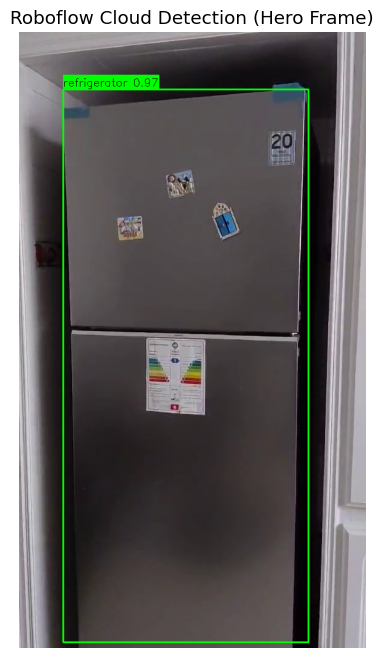

[1] Class: REFRIGERATOR | Confidence: 0.97 | BBox: x=0.0, y=0.0


In [ ]:
from app.services.roboflow_service import RoboflowService

print("Initializing Roboflow Service (Cloud API)...")
roboflow = RoboflowService()

print("Sending Hero Frame (Frame 96) to Roboflow custom-workflow-3...")
rf_response = roboflow.detect(pil_sharp, workflow_id="custom-workflow-3")
rf_hits = rf_response.get('detections', [])

print(f"\nRoboflow Response Summary:")
print(f"Detected {len(rf_hits)} objects.")

if rf_hits:
    # We will draw the Roboflow boxes just like we did with YOLO
    rf_drawn = yolo.draw_detections(pil_sharp, rf_hits)
    
    plt.figure(figsize=(10, 8))
    plt.imshow(rf_drawn)
    plt.title(f"Roboflow Cloud Detection (Hero Frame)")
    plt.axis('off')
    plt.show()
    
    for i, hit in enumerate(rf_hits):
        print(f"[{i+1}] Class: {hit['class'].upper()} | Confidence: {hit['confidence']:.2f} | BBox: x={hit.get('x',0):.1f}, y={hit.get('y',0):.1f}")
else:
    print("No detections returned from Roboflow.")

---
## Part 4: Exploratory Data Analysis - Aspect Ratios
Different appliances have distinctly different form factors. We run YOLOv5 over a subset of frames to compute the real Aspect Ratio (Width / Height) distribution.

Scanning video frames to build geometric clusters...


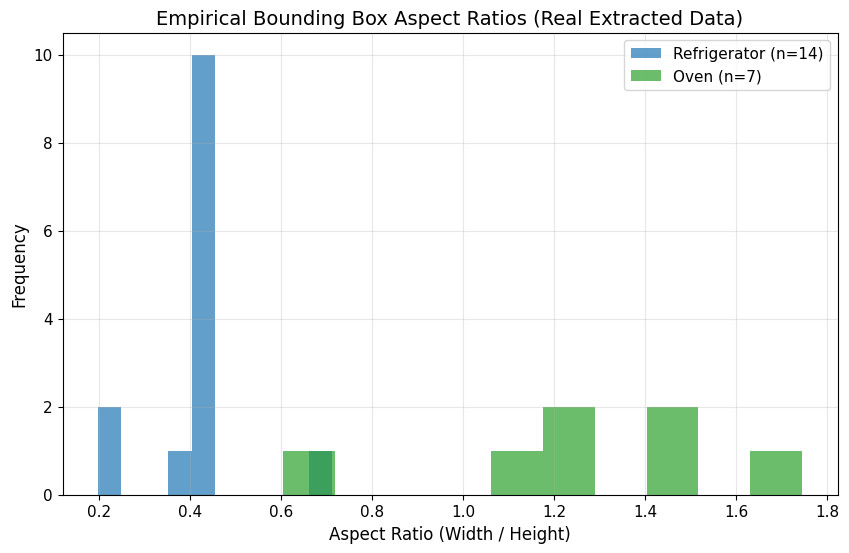

In [ ]:
aspect_ratios = {}
print("Scanning video frames to build geometric clusters...")

for frame_idx in range(0, total_frames, 10): # Sample every 10 frames
    cap.set(cv2.CAP_PROP_POS_FRAMES, frame_idx)
    ret, frame = cap.read()
    if not ret: continue
        
    pil_img = Image.fromarray(cv2.cvtColor(frame, cv2.COLOR_BGR2RGB))
    hits = yolo.detect(pil_img)
    
    for h in hits:
        x1, y1, x2, y2 = h['bbox']
        w, h_box = x2 - x1, y2 - y1
        if h_box > 0:
            ar = w / h_box
            cls = h['class']
            if cls not in aspect_ratios: aspect_ratios[cls] = []
            aspect_ratios[cls].append(ar)

# Plotting the Geometric Clusters
plt.figure(figsize=(10, 6))
colors = ['#1f77b4', '#ff7f0e', '#2ca02c']
target_classes = ['refrigerator', 'microwave', 'oven']

for i, cls in enumerate(target_classes):
    if cls in aspect_ratios:
        plt.hist(aspect_ratios[cls], bins=10, alpha=0.7, label=f"{cls.capitalize()} (n={len(aspect_ratios[cls])})", color=colors[i%len(colors)])

plt.title("Empirical Bounding Box Aspect Ratios (Real Extracted Data)", fontsize=14)
plt.xlabel("Aspect Ratio (Width / Height)", fontsize=12)
plt.ylabel("Frequency", fontsize=12)
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

---
## Part 5: Visual Data Preparation (CLAHE & Upscaling)
Once a bounding box is isolated from the Hero Frame, we apply **Contrast Limited Adaptive Histogram Equalization (CLAHE)** to recover shadow detail and prepare the crop for the Gemini Vision model.

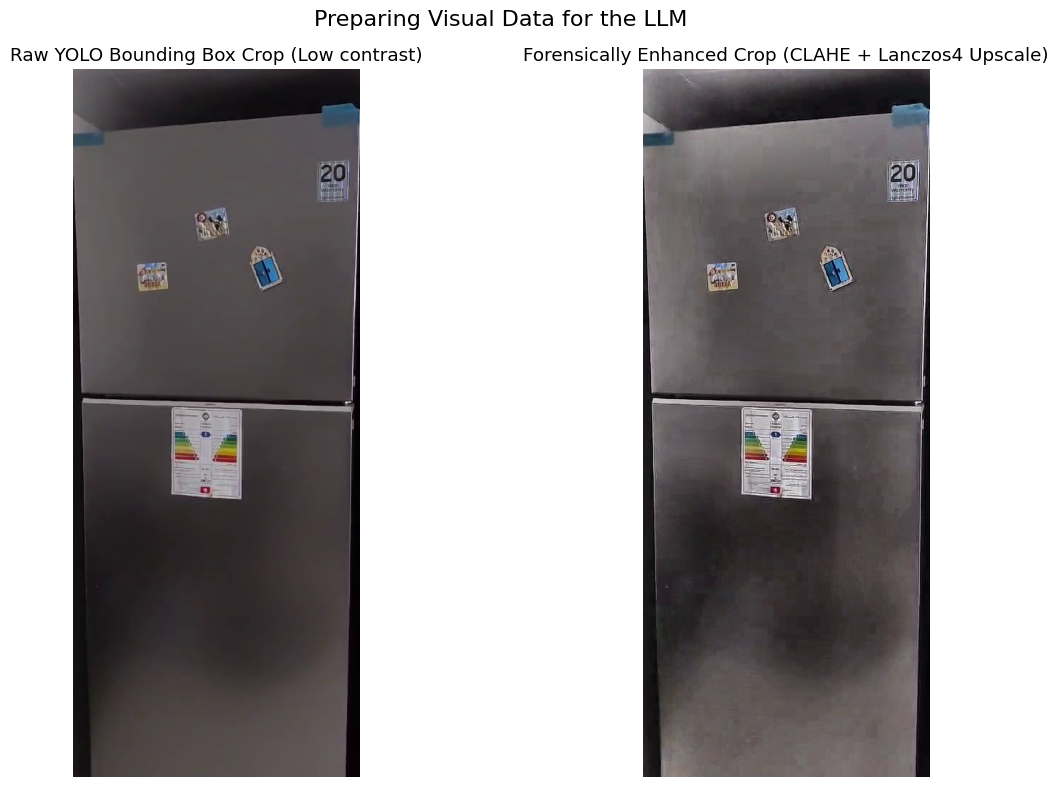

In [ ]:
vision_rag = VisionRAGService()

# Simulate a tight bounding box crop using the YOLO detection from Frame 96
if len(sharp_hits) > 0:
    best_hit = max(sharp_hits, key=lambda x: x['confidence'])
    x1, y1, x2, y2 = [int(v) for v in best_hit['bbox']]
    
    # Raw crop from BGR frame
    raw_crop_bgr = sharp_frame[y1:y2, x1:x2]
    
    # Run the VisionRAG Enhancement Pipeline
    enhanced_crop_bgr = vision_rag.enhance_crop_for_ocr(raw_crop_bgr)
    
    fig, axes = plt.subplots(1, 2, figsize=(14, 8))
    axes[0].imshow(cv2.cvtColor(raw_crop_bgr, cv2.COLOR_BGR2RGB))
    axes[0].set_title("Raw YOLO Bounding Box Crop (Low contrast)")
    axes[0].axis('off')
    
    axes[1].imshow(cv2.cvtColor(enhanced_crop_bgr, cv2.COLOR_BGR2RGB))
    axes[1].set_title("Forensically Enhanced Crop (CLAHE + Lanczos4 Upscale)")
    axes[1].axis('off')
    
    plt.suptitle("Preparing Visual Data for the LLM", fontsize=16)
    plt.tight_layout()
    plt.show()
else:
    print("No bounding box found to crop.")

cap.release()

---
## Part 6: Text Data Preparation (Web Scraping DOM Cleaning)
Unstructured web data is extremely bloated. If we pass raw HTML to Gemini, it poisons the context window. We use BeautifulSoup to decompose boilerplate nodes (scripts, nav, styling).

In [ ]:
from bs4 import BeautifulSoup
import textwrap

# Simulate a raw HTML product page
raw_html = """
<html>
    <head><style>.btn { color: red; }</style><script>analytics.track('view');</script></head>
    <body>
        <nav><ul><li>Home</li><li>Products</li><li>Cart</li></ul></nav>
        <div class="main-content">
            <h1>Samsung Refrigerator 380L</h1>
            <table class="specs">
                <tr><td>Brand</td><td>Samsung</td></tr>
                <tr><td>Energy Class</td><td>A+++</td></tr>
            </table>
        </div>
        <footer>Copyright 2026 Tunisianet. All rights reserved.</footer>
        <script>loadAds();</script>
    </body>
</html>
"""

def clean_dom_payload(html_content):
    soup = BeautifulSoup(html_content, 'html.parser')
    # Remove boilerplate nodes
    for tag in soup(['script', 'style', 'nav', 'footer', 'header', 'aside', 'noscript', 'form', 'button']):
        tag.decompose()
    # Extract just the visible text
    text = soup.get_text(separator=' | ', strip=True)
    return text

cleaned_text = clean_dom_payload(raw_html)

print(f"RAW HTML SIZE: {len(raw_html)} characters")
print(f"CLEAN TEXT SIZE: {len(cleaned_text)} characters")
print(f"COMPRESSION RATIO: {(1 - len(cleaned_text)/len(raw_html))*100:.1f}% reduction\n")

print("--- CLEANED PAYLOAD SENT TO GEMINI ---")
print(textwrap.fill(cleaned_text, width=80))

RAW HTML SIZE: 582 characters
CLEAN TEXT SIZE: 65 characters
COMPRESSION RATIO: 88.8% reduction

--- CLEANED PAYLOAD SENT TO GEMINI ---
Samsung Refrigerator 380L | Brand | Samsung | Energy Class | A+++
